Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

Missing Values Before Cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Non-numeric horsepower values: <StringArray>
['?']
Length: 1, dtype: str

Missing Values After Replacing '?':
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_96180/194032342.py:37: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['horsepower'].replace('?', np.nan, inplace=True)
/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_96180/194032342.py:45: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

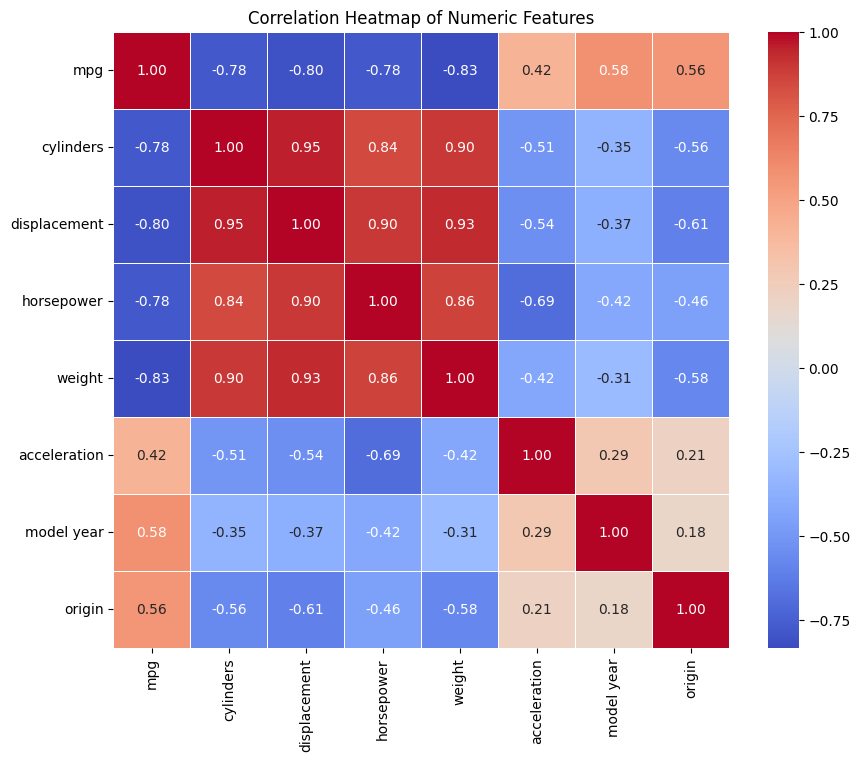

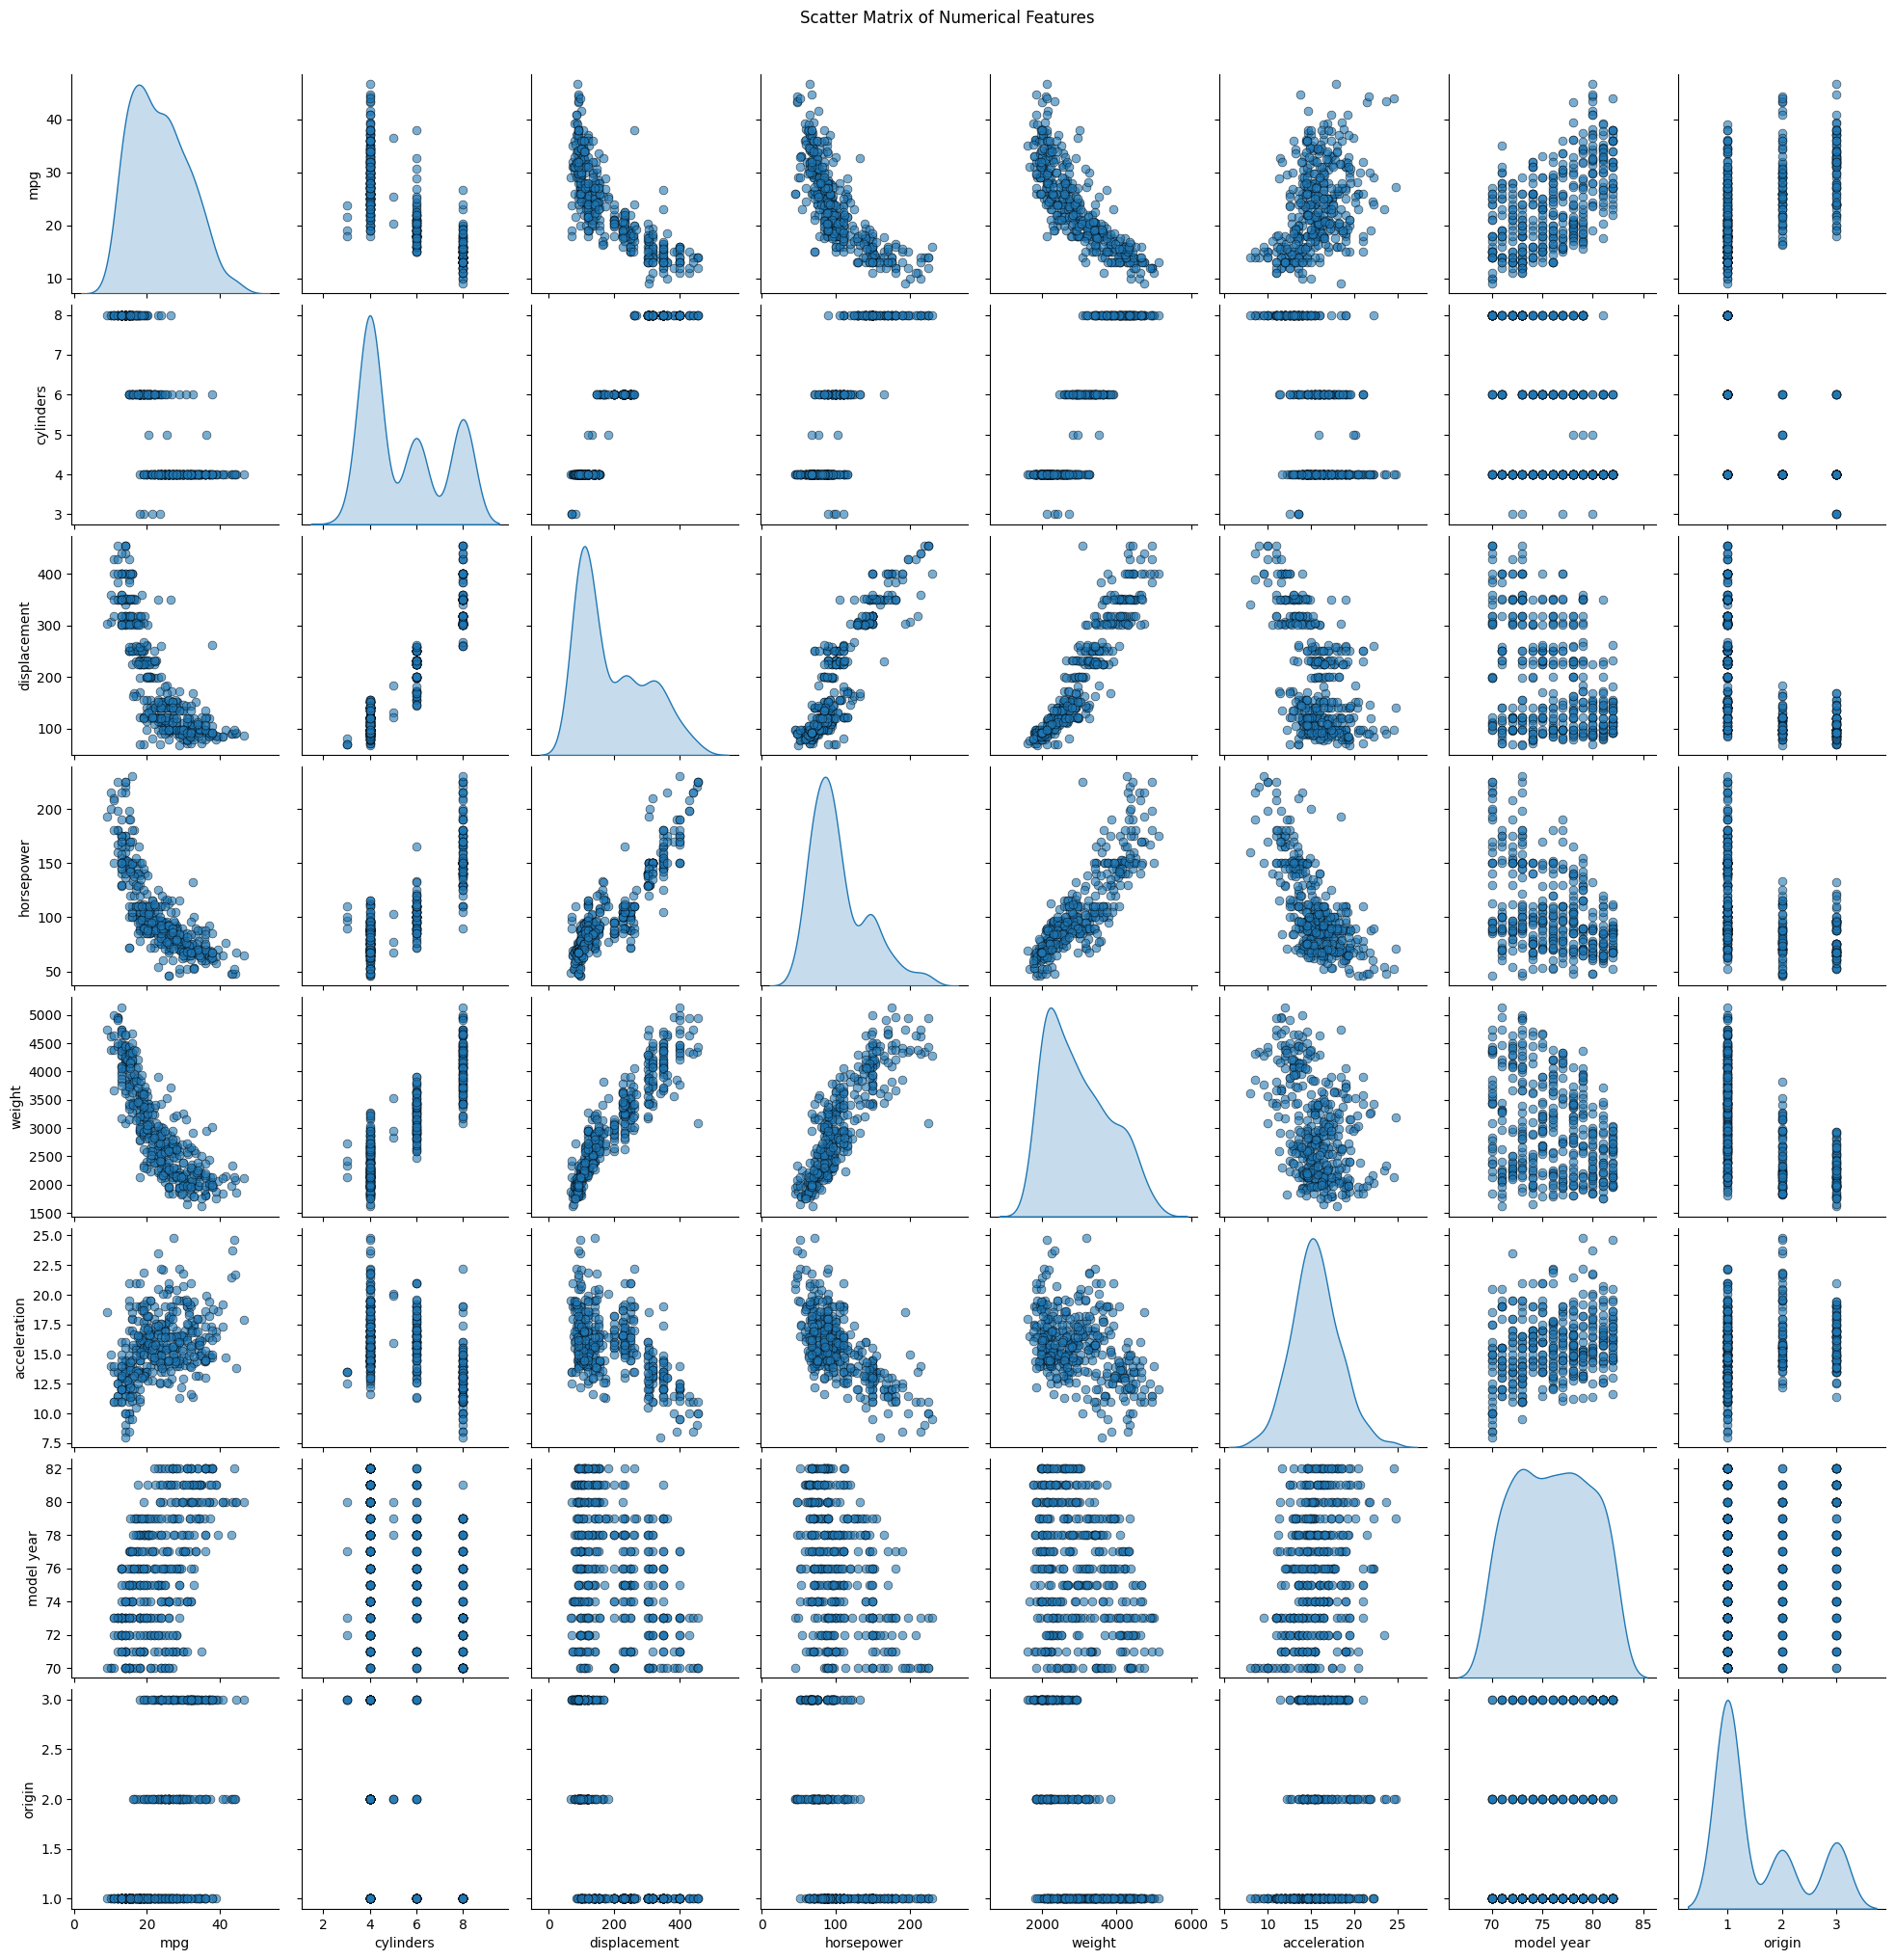


Variance Inflation Factor:
        Feature         VIF
0         const  772.092426
1           mpg    5.242609
2     cylinders   10.660295
3  displacement   19.697244
4    horsepower    9.398062
5        weight   13.598221
6  acceleration    2.630344
7    model year    1.907643


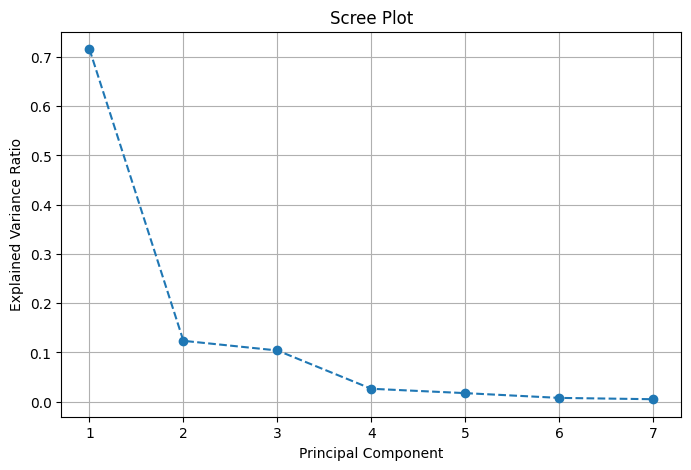


Explained Variance per Principal Component:


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.7158,0.7158
1,PC2,0.1237,0.8395
2,PC3,0.1041,0.9435
3,PC4,0.0263,0.9698
4,PC5,0.0174,0.9872
5,PC6,0.0078,0.9950
6,PC7,0.0050,1.0000



Principal Component Loadings:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
mpg,-0.3981,0.2068,-0.2572,0.7510,0.3408,0.2098,-0.0922
cylinders,0.4161,0.1985,0.1392,0.4773,-0.4932,-0.3325,-0.4317
displacement,0.4293,0.1804,0.1003,0.2978,-0.0566,0.1430,0.8129
horsepower,0.4228,0.0852,-0.1697,-0.0421,0.7113,-0.5228,-0.0644
weight,0.4140,0.2247,0.2761,-0.1077,0.2652,0.6965,-0.3672
acceleration,-0.2849,-0.0070,0.8933,0.1211,0.2308,-0.2238,0.0528
model year,-0.2295,0.9097,-0.0372,-0.3024,-0.0890,-0.1282,0.0511



Top 3 Principal Components:


,PC1,PC2,PC3
0,2.635049,-0.929039,-0.534679
1,3.493800,-0.805473,-0.649495
2,2.970415,-0.881186,-0.958742
3,2.910197,-0.961721,-0.582953
4,2.903826,-0.952789,-1.054836


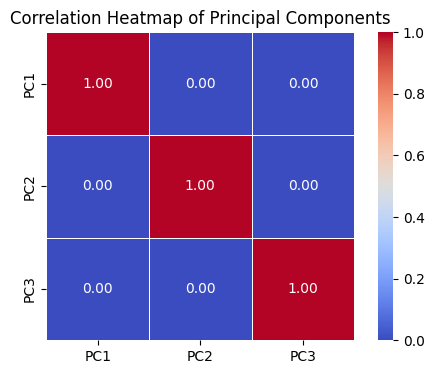

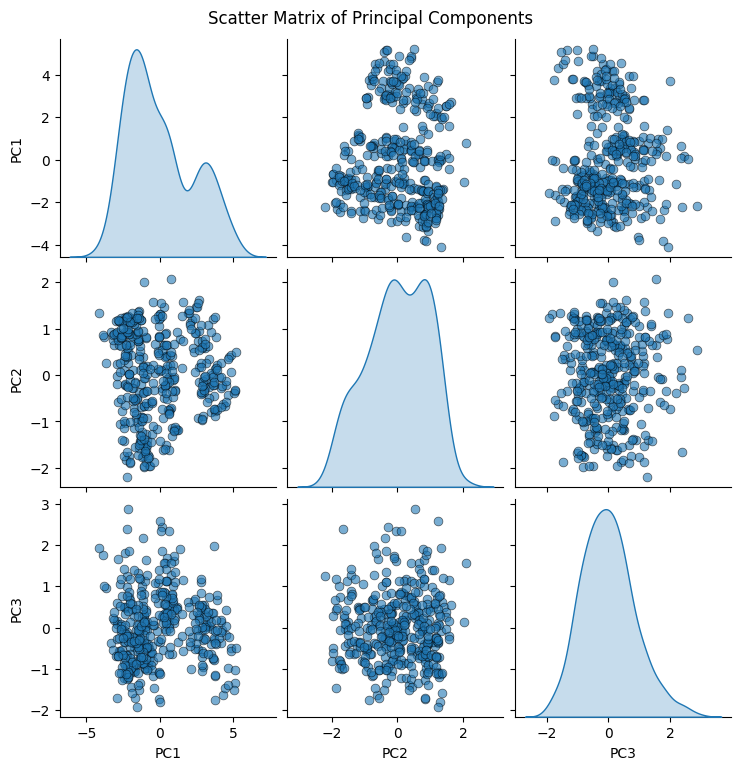

In [9]:
# =========================
# CARGA DE DATOS
# =========================
file_path = '../../data/s1/e4/auto-mpg.csv'

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(file_path)

# =========================
# TIPOS DE DATOS
# =========================

print("Data Types:")
print(df.dtypes)

# =========================
# VALORES FALTANTES
# =========================

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Buscar valores no numéricos en horsepower
non_numeric_hp = df[~df['horsepower'].astype(str).str.replace('.', '', 1).str.isnumeric()]['horsepower'].unique()
print("\nNon-numeric horsepower values:", non_numeric_hp)

# Reemplazar '?' por NaN y convertir a numérico
df['horsepower'].replace('?', np.nan, inplace=True)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

print("\nMissing Values After Replacing '?':")
print(df.isnull().sum())

# Rellenar NaN con la media
mean_hp = df['horsepower'].mean()
df['horsepower'].fillna(mean_hp, inplace=True)

# =========================
# HEATMAP DE CORRELACIÓN
# =========================

corr = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# =========================
# SCATTER MATRIX ORIGINAL
# =========================

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numeric_df, diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})
plt.suptitle("Scatter Matrix of Numerical Features", y=1.02)
plt.show()

# =========================
# VIF (Multicolinealidad)
# =========================

X_vif = df.drop(columns=['car name', 'origin'])
X_vif = add_constant(X_vif)

# Remove rows with inf or nan values
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\nVariance Inflation Factor:")
print(vif)

# =========================
# PCA
# =========================
X = df.drop(columns=['car name', 'origin'])
# Elimina cualquier fila con NaN antes de PCA (por seguridad extra)
X_no_nan = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_nan)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# =========================
# SCREE PLOT (MATPLOTLIB)
# =========================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

# =========================
# SCREE PLOT INTERACTIVO
# =========================

components = list(range(1, len(pca.explained_variance_ratio_) + 1))
variance_ratio = pca.explained_variance_ratio_

fig = px.line(
    x=components,
    y=variance_ratio,
    markers=True,
    labels={"x": "Principal Component", "y": "Explained Variance Ratio"},
    title="Scree Plot"
)

fig.show()

# =========================
# TABLA DE VARIANZA EXPLICADA
# =========================

explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nExplained Variance per Principal Component:")
display(explained_variance.round(4))

# =========================
# LOADINGS DEL PCA
# =========================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.columns
)

print("\nPrincipal Component Loadings:")
display(loadings.round(4))

# =========================
# PRIMERAS 3 COMPONENTES
# =========================

X_pca_3 = X_pca[:, :3]

df_pca = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])

print("\nTop 3 Principal Components:")
display(df_pca.head())

# =========================
# CORRELACIÓN ENTRE PCs
# =========================

corr_pca = df_pca[['PC1', 'PC2', 'PC3']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_pca, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Principal Components")
plt.show()

# =========================
# SCATTER MATRIX DE PCs
# =========================

sns.pairplot(df_pca[['PC1', 'PC2', 'PC3']],
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})
plt.suptitle("Scatter Matrix of Principal Components", y=1.02)
plt.show()